# Sprint 2 — EDA + Feature Engineering
### modelo-risco-sinistralidade-b2b

Este notebook conecta no Postgres (container Docker `risco_sinistralidade_db`),
carrega os dados de `dim_empresa`, `fato_apolice` e `fato_sinistro`, e conduz
a análise exploratória + engenharia de atributos para o modelo de sinistralidade.

**Pré-requisito:** os containers Docker devem estar rodando (`docker compose up -d`)
e a porta `5432` exposta no `localhost`.


## 1. Setup e conexão com o banco

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Conexão com o Postgres (container Docker exposto em localhost:5432)
DB_USER = "postgres"
DB_PASS = "postgres"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "risco_sinistralidade_dw"

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("Conexão criada com sucesso.")


Conexão criada com sucesso.


## 2. Carga dos dados

In [25]:
query = '''
SELECT
    e.empresa_id,
    e.razao_social,
    e.setor,
    e.porte,
    e.tempo_mercado_anos,
    e.estado,
    e.faturamento_anual,
    e.num_funcionarios,
    a.apolice_id,
    a.cobertura,
    a.valor_segurado,
    a.premio_anual,
    a.franquia,
    a.data_inicio,
    a.data_fim,
    a.teve_sinistro
FROM dim_empresa e
JOIN fato_apolice a ON a.empresa_id = e.empresa_id
'''

df = pd.read_sql(query, engine)
print(df.shape)
df.head()


(10060, 16)


,empresa_id,razao_social,setor,porte,tempo_mercado_anos,estado,faturamento_anual,num_funcionarios,apolice_id,cobertura,valor_segurado,premio_anual,franquia,data_inicio,data_fim,teve_sinistro
0,EMP000079,Ferreira e Filhos,saude,MEI,3.9,PE,132520.45,1,APL0000156,frota,10492.77,140.33,222.56,2022-11-14,2023-11-14,False
1,EMP000005,Martins,alimenticio,MEI,11.9,SP,192758.31,1,APL0000010,frota,33714.13,685.23,1286.20,2025-10-23,2026-10-23,True
2,EMP001113,Cassiano,transporte_logistica,micro,0.8,RJ,4208266.21,25,APL0002216,frota,1123498.08,13614.76,15353.00,2024-12-07,2025-12-07,True
3,EMP001482,Farias - EI,construcao_civil,micro,5.4,SP,1290982.67,8,APL0002903,cyber,166290.15,3367.77,5768.83,2022-09-03,2023-09-03,False
4,EMP001914,Rios,servicos_financeiros,MEI,8.5,MG,175820.68,1,APL0003813,frota,53878.11,599.86,2320.64,2024-07-17,2025-07-17,False


In [26]:
query_sinistros = '''
SELECT sinistro_id, apolice_id, empresa_id, tipo_sinistro, data_sinistro, valor_sinistro, status
FROM fato_sinistro
'''

df_sinistros = pd.read_sql(query_sinistros, engine)
print(df_sinistros.shape)
df_sinistros.head()


(2265, 7)


,sinistro_id,apolice_id,empresa_id,tipo_sinistro,data_sinistro,valor_sinistro,status
0,SIN0000001,APL0000001,EMP000001,avaria,2024-01-24,7629.34,em_analise
1,SIN0000002,APL0000002,EMP000001,processo_trabalhista,2024-07-17,8742.41,pago
2,SIN0000003,APL0000010,EMP000005,avaria,2025-11-12,15244.84,negado
3,SIN0000004,APL0000015,EMP000007,colisao,2024-02-28,3669287.00,pago
4,SIN0000005,APL0000020,EMP000010,avaria,2022-05-14,57093.50,pago


## 3. Qualidade dos dados

Checagem de nulos, tipos e inconsistências antes de seguir com a análise.


In [27]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10060 entries, 0 to 10059
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   empresa_id          10060 non-null  object 
 1   razao_social        10060 non-null  object 
 2   setor               10060 non-null  object 
 3   porte               10060 non-null  object 
 4   tempo_mercado_anos  10060 non-null  float64
 5   estado              10060 non-null  object 
 6   faturamento_anual   10060 non-null  float64
 7   num_funcionarios    10060 non-null  int64  
 8   apolice_id          10060 non-null  object 
 9   cobertura           10060 non-null  object 
 10  valor_segurado      10060 non-null  float64
 11  premio_anual        10060 non-null  float64
 12  franquia            10060 non-null  float64
 13  data_inicio         10060 non-null  object 
 14  data_fim            10060 non-null  object 
 15  teve_sinistro       10060 non-null  bool   
dtypes: b

In [28]:
# Nulos por coluna
df.isnull().sum().sort_values(ascending=False)


empresa_id            0
razao_social          0
setor                 0
porte                 0
tempo_mercado_anos    0
estado                0
faturamento_anual     0
num_funcionarios      0
apolice_id            0
cobertura             0
valor_segurado        0
premio_anual          0
franquia              0
data_inicio           0
data_fim              0
teve_sinistro         0
dtype: int64

In [29]:
# Inconsistências de datas: data_fim antes de data_inicio
inconsistentes = df[df["data_fim"] < df["data_inicio"]]
print(f"Apólices com data_fim < data_inicio: {len(inconsistentes)}")

# tempo_mercado_anos negativo
print(f"Empresas com tempo_mercado_anos < 0: {(df['tempo_mercado_anos'] < 0).sum()}")


Apólices com data_fim < data_inicio: 0
Empresas com tempo_mercado_anos < 0: 0


## 4. Análise univariada (distribuições)

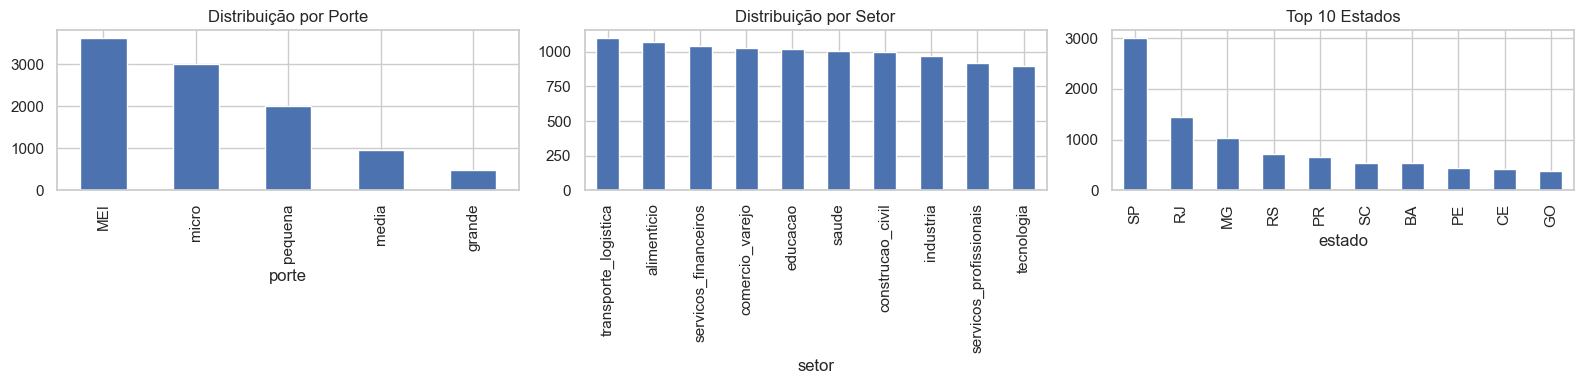

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df["porte"].value_counts().plot(kind="bar", ax=axes[0], title="Distribuição por Porte")
df["setor"].value_counts().plot(kind="bar", ax=axes[1], title="Distribuição por Setor")
df["estado"].value_counts().head(10).plot(kind="bar", ax=axes[2], title="Top 10 Estados")

plt.tight_layout()
plt.show()


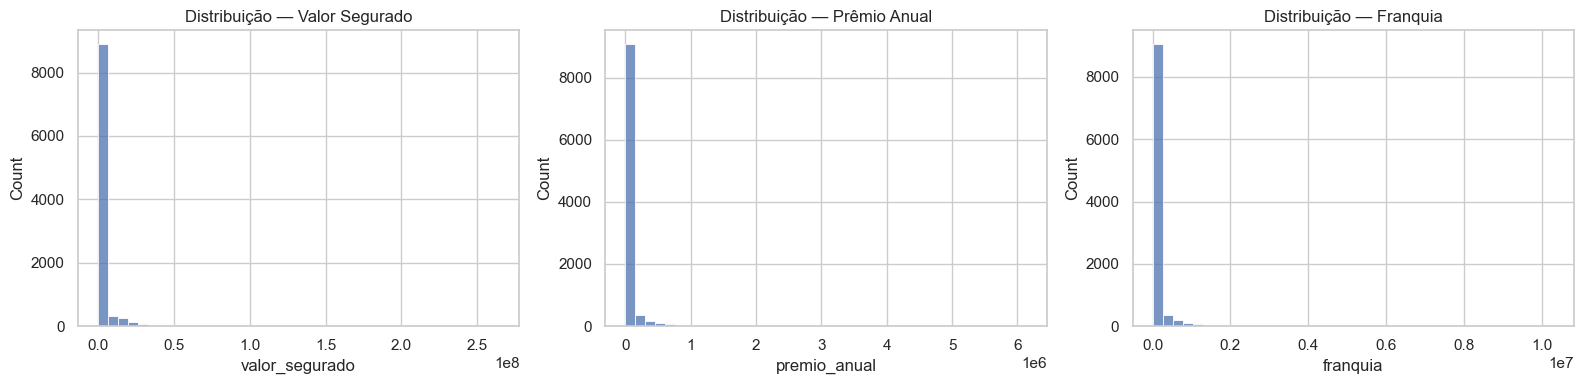

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df["valor_segurado"], bins=40, ax=axes[0])
axes[0].set_title("Distribuição — Valor Segurado")

sns.histplot(df["premio_anual"], bins=40, ax=axes[1])
axes[1].set_title("Distribuição — Prêmio Anual")

sns.histplot(df["franquia"], bins=40, ax=axes[2])
axes[2].set_title("Distribuição — Franquia")

plt.tight_layout()
plt.show()


## 5. Sinistralidade por dimensão

Aqui está o núcleo da EDA: como a taxa de sinistro (`teve_sinistro`) varia
por cada dimensão categórica e faixa numérica.


In [32]:
def taxa_sinistro_por(col, top_n=None):
    tab = df.groupby(col)["teve_sinistro"].agg(["mean", "count"]).sort_values("mean", ascending=False)
    tab.columns = ["taxa_sinistro", "n_apolices"]
    if top_n:
        tab = tab.head(top_n)
    return tab

taxa_sinistro_por("setor")


,taxa_sinistro,n_apolices
setor,,
construcao_civil,0.308000,1000
transporte_logistica,0.281818,1100
industria,0.225207,968
alimenticio,0.170093,1070
comercio_varejo,0.154820,1027
saude,0.147671,1009
educacao,0.126223,1022
servicos_financeiros,0.114203,1042
servicos_profissionais,0.096529,922


In [33]:
taxa_sinistro_por("porte")


,taxa_sinistro,n_apolices
porte,,
MEI,0.194268,3629
micro,0.181304,3006
pequena,0.156344,2002
media,0.138947,950
grande,0.114165,473


In [34]:
taxa_sinistro_por("cobertura")


,taxa_sinistro,n_apolices
cobertura,,
frota,0.245926,2025
riscos_operacionais,0.194944,2057
patrimonial,0.162190,1973
responsabilidade_civil,0.138971,2022
cyber,0.125567,1983


In [35]:
taxa_sinistro_por("estado", top_n=15)


,taxa_sinistro,n_apolices
estado,,
PA,0.224771,218
PE,0.204598,435
RJ,0.181628,1437
PR,0.180000,650
RS,0.179416,719
AM,0.178744,207
CE,0.177725,422
SC,0.175926,540
SP,0.174767,3004


In [36]:
# Faixas de tempo de mercado
bins_tempo = [0, 2, 5, 10, 20, np.inf]
labels_tempo = ["0-2", "3-5", "6-10", "11-20", "20+"]
df["faixa_tempo_mercado"] = pd.cut(df["tempo_mercado_anos"], bins=bins_tempo, labels=labels_tempo, right=True)

taxa_sinistro_por("faixa_tempo_mercado")


/var/folders/79/0vmysjhs5c93hhh6z06v9zq80000gn/T/ipykernel_26073/3581774972.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = df.groupby(col)["teve_sinistro"].agg(["mean", "count"]).sort_values("mean", ascending=False)


,taxa_sinistro,n_apolices
faixa_tempo_mercado,,
0-2,0.254598,1033
3-5,0.199172,2656
11-20,0.152267,2338
6-10,0.150818,3607
20+,0.133803,426


In [37]:
# Faixas de faturamento anual (quartis)
df["faixa_faturamento"] = pd.qcut(df["faturamento_anual"], q=4, labels=["Q1 (menor)", "Q2", "Q3", "Q4 (maior)"])

taxa_sinistro_por("faixa_faturamento")


/var/folders/79/0vmysjhs5c93hhh6z06v9zq80000gn/T/ipykernel_26073/3581774972.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = df.groupby(col)["teve_sinistro"].agg(["mean", "count"]).sort_values("mean", ascending=False)


,taxa_sinistro,n_apolices
faixa_faturamento,,
Q1 (menor),0.190382,2516
Q2,0.186083,2515
Q3,0.173429,2514
Q4 (maior),0.145527,2515


In [38]:
# Faixas de número de funcionários (quartis)
df["faixa_funcionarios"] = pd.qcut(df["num_funcionarios"], q=4, labels=["Q1 (menor)", "Q2", "Q3", "Q4 (maior)"], duplicates="drop")

taxa_sinistro_por("faixa_funcionarios")


/var/folders/79/0vmysjhs5c93hhh6z06v9zq80000gn/T/ipykernel_26073/3581774972.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = df.groupby(col)["teve_sinistro"].agg(["mean", "count"]).sort_values("mean", ascending=False)


,taxa_sinistro,n_apolices
faixa_funcionarios,,
Q1 (menor),0.189640,3417
Q2,0.187077,1625
Q3,0.170927,2504
Q4 (maior),0.146778,2514


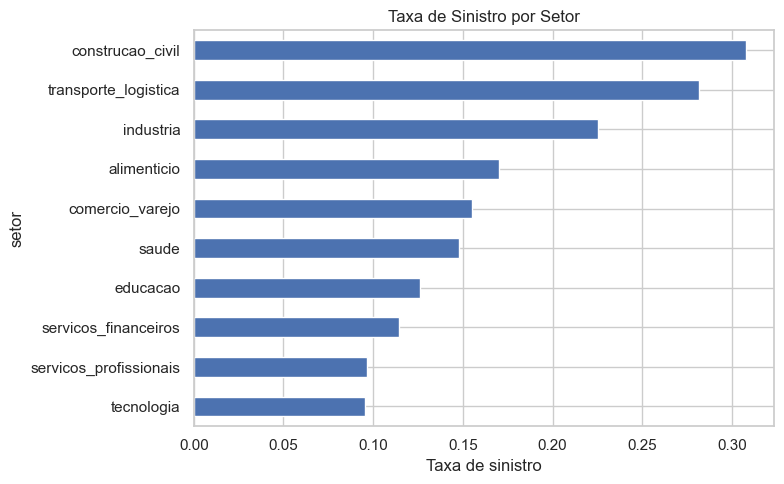

In [39]:
fig, ax = plt.subplots(figsize=(8, 5))
taxa_sinistro_por("setor")["taxa_sinistro"].sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Taxa de Sinistro por Setor")
ax.set_xlabel("Taxa de sinistro")
plt.tight_layout()
plt.show()


## 6. Variáveis contínuas vs. o target

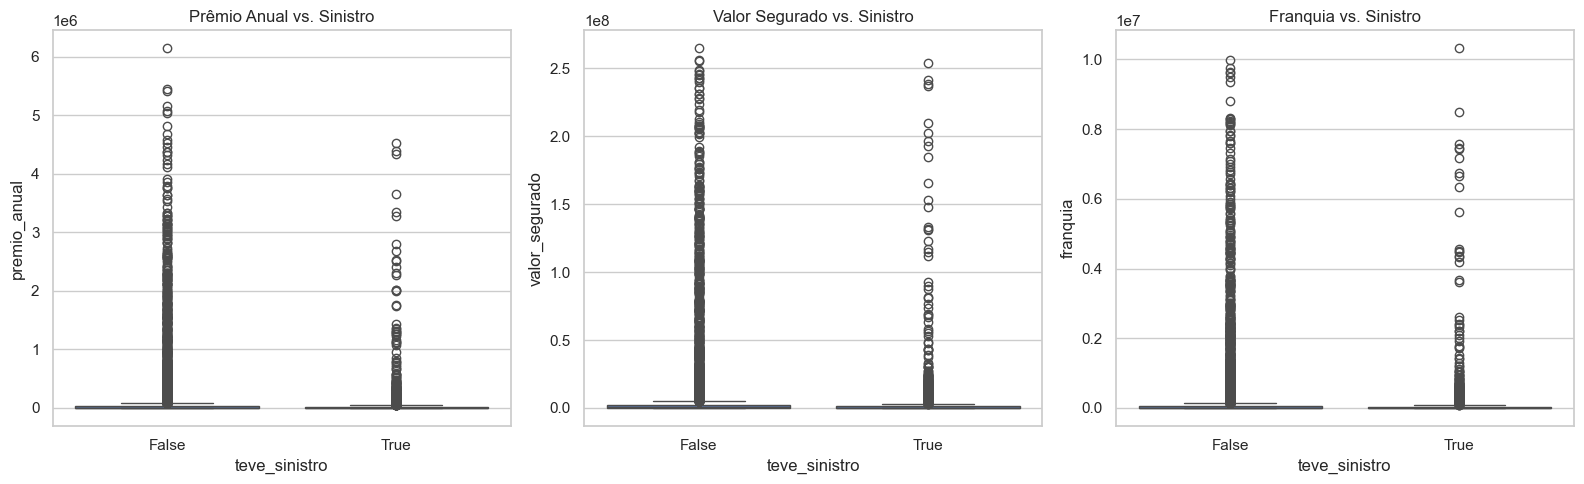

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x="teve_sinistro", y="premio_anual", ax=axes[0])
axes[0].set_title("Prêmio Anual vs. Sinistro")

sns.boxplot(data=df, x="teve_sinistro", y="valor_segurado", ax=axes[1])
axes[1].set_title("Valor Segurado vs. Sinistro")

sns.boxplot(data=df, x="teve_sinistro", y="franquia", ax=axes[2])
axes[2].set_title("Franquia vs. Sinistro")

plt.tight_layout()
plt.show()


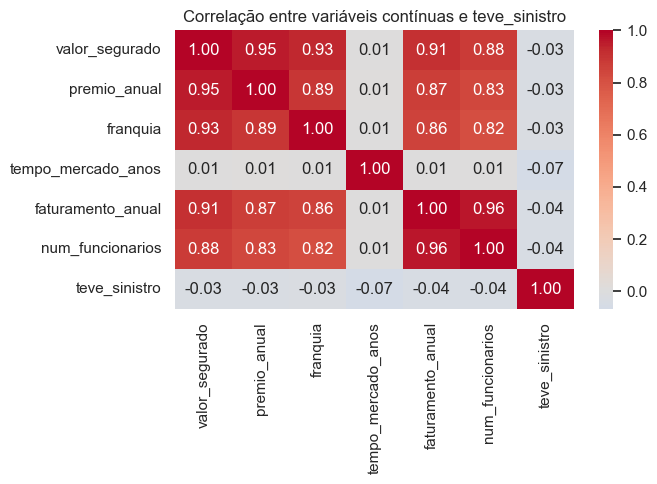

In [41]:
cont_cols = ["valor_segurado", "premio_anual", "franquia", "tempo_mercado_anos",
             "faturamento_anual", "num_funcionarios", "teve_sinistro"]

corr = df[cont_cols].corr(numeric_only=True)

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlação entre variáveis contínuas e teve_sinistro")
plt.tight_layout()
plt.show()


## 7. Análise temporal

Sazonalidade de sinistros e tempo médio entre início da apólice e a ocorrência do sinistro.


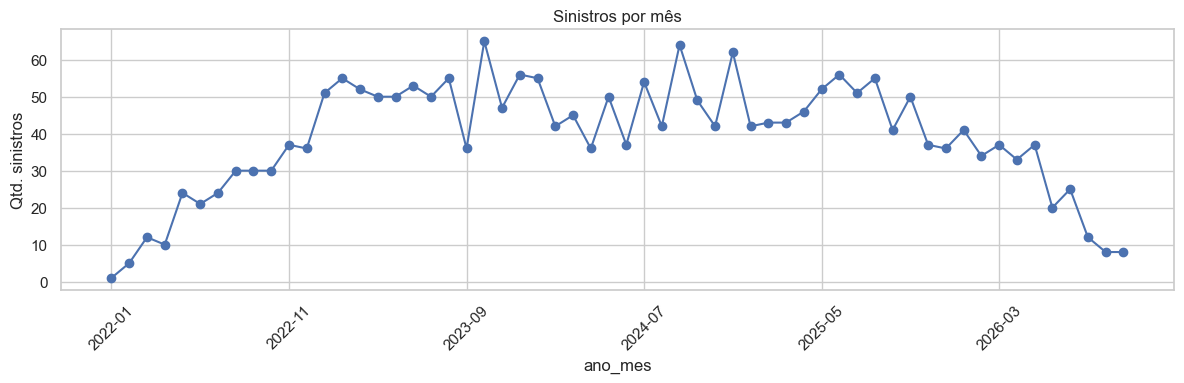

In [42]:
df_sinistros["data_sinistro"] = pd.to_datetime(df_sinistros["data_sinistro"])
df_sinistros["ano_mes"] = df_sinistros["data_sinistro"].dt.to_period("M").astype(str)

sinistros_por_mes = df_sinistros.groupby("ano_mes").size()

plt.figure(figsize=(12, 4))
sinistros_por_mes.plot(kind="line", marker="o")
plt.title("Sinistros por mês")
plt.ylabel("Qtd. sinistros")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


count    2265.000000
mean      183.999117
std       106.624088
min         1.000000
25%        92.000000
50%       184.000000
75%       279.000000
max       364.000000
Name: dias_ate_sinistro, dtype: float64


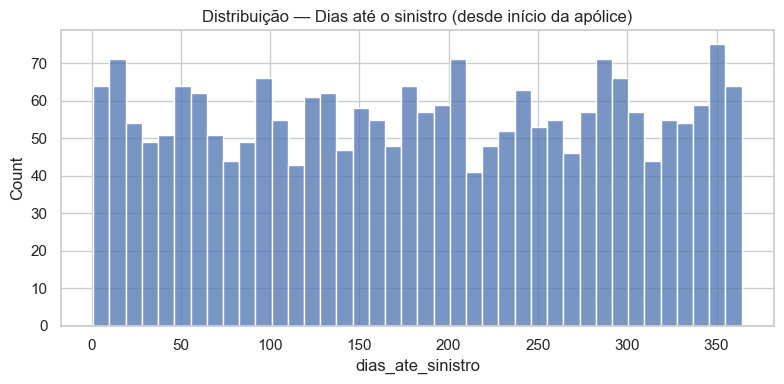

In [43]:
# Tempo entre início da apólice e o sinistro
df_merged = df_sinistros.merge(
    df[["apolice_id", "data_inicio"]].drop_duplicates(), on="apolice_id", how="left"
)
df_merged["data_inicio"] = pd.to_datetime(df_merged["data_inicio"])
df_merged["dias_ate_sinistro"] = (df_merged["data_sinistro"] - df_merged["data_inicio"]).dt.days

print(df_merged["dias_ate_sinistro"].describe())

plt.figure(figsize=(8, 4))
sns.histplot(df_merged["dias_ate_sinistro"], bins=40)
plt.title("Distribuição — Dias até o sinistro (desde início da apólice)")
plt.tight_layout()
plt.show()


## 8. Feature engineering

Consolidando as features derivadas que serão usadas no Sprint 3 (modelo preditivo).


In [44]:
# Quantidade de sinistros históricos por empresa (uma empresa pode ter várias apólices/sinistros)
sinistros_por_empresa = df_sinistros.groupby("empresa_id").size().rename("qtd_sinistros_historico")

df = df.merge(sinistros_por_empresa, on="empresa_id", how="left")
df["qtd_sinistros_historico"] = df["qtd_sinistros_historico"].fillna(0).astype(int)

# Razão prêmio / valor segurado (proxy de "preço de risco" percebido)
df["razao_premio_valor_segurado"] = df["premio_anual"] / df["valor_segurado"]

df[["empresa_id", "qtd_sinistros_historico", "razao_premio_valor_segurado"]].head()


,empresa_id,qtd_sinistros_historico,razao_premio_valor_segurado
0,EMP000079,0,0.013374
1,EMP000005,1,0.020325
2,EMP001113,3,0.012118
3,EMP001482,0,0.020252
4,EMP001914,1,0.011134


In [45]:
# One-hot encoding das categóricas para o dataset de modelagem
cat_cols = ["setor", "porte", "estado", "cobertura", "faixa_tempo_mercado", "faixa_faturamento", "faixa_funcionarios"]

df_model = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(df_model.shape)
df_model.head()


(10060, 54)


,empresa_id,razao_social,tempo_mercado_anos,faturamento_anual,num_funcionarios,apolice_id,valor_segurado,premio_anual,franquia,data_inicio,data_fim,teve_sinistro,qtd_sinistros_historico,razao_premio_valor_segurado,setor_comercio_varejo,setor_construcao_civil,setor_educacao,setor_industria,setor_saude,setor_servicos_financeiros,setor_servicos_profissionais,setor_tecnologia,setor_transporte_logistica,porte_grande,porte_media,porte_micro,porte_pequena,estado_BA,estado_CE,estado_DF,estado_GO,estado_MA,estado_MG,estado_PA,estado_PE,estado_PR,estado_RJ,estado_RS,estado_SC,estado_SP,cobertura_frota,cobertura_patrimonial,cobertura_responsabilidade_civil,cobertura_riscos_operacionais,faixa_tempo_mercado_3-5,faixa_tempo_mercado_6-10,faixa_tempo_mercado_11-20,faixa_tempo_mercado_20+,faixa_faturamento_Q2,faixa_faturamento_Q3,faixa_faturamento_Q4 (maior),faixa_funcionarios_Q2,faixa_funcionarios_Q3,faixa_funcionarios_Q4 (maior)
0,EMP000079,Ferreira e Filhos,3.9,132520.45,1,APL0000156,10492.77,140.33,222.56,2022-11-14,2023-11-14,False,0,0.013374,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False
1,EMP000005,Martins,11.9,192758.31,1,APL0000010,33714.13,685.23,1286.20,2025-10-23,2026-10-23,True,1,0.020325,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,True,False,False,False,False,False,False,False
2,EMP001113,Cassiano,0.8,4208266.21,25,APL0002216,1123498.08,13614.76,15353.00,2024-12-07,2025-12-07,True,3,0.012118,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False
3,EMP001482,Farias - EI,5.4,1290982.67,8,APL0002903,166290.15,3367.77,5768.83,2022-09-03,2023-09-03,False,0,0.020252,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,True,False,False
4,EMP001914,Rios,8.5,175820.68,1,APL0003813,53878.11,599.86,2320.64,2024-07-17,2025-07-17,False,1,0.011134,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False


In [46]:
# Exporta o dataset já com as features para o Sprint 3
df_model.to_csv("../data/dataset_features.csv", index=False)
print("Dataset salvo em data/dataset_features.csv")


Dataset salvo em data/dataset_features.csv


## 9. Principais achados (preencher após rodar)

- Setor com maior taxa de sinistro: _...
- Porte com maior taxa de sinistro: _...
- Correlação mais forte com `teve_sinistro`: _...
- Sazonalidade observada: _...
- Features mais promissoras para o Sprint 3: _...
